In [3]:
import pandas as pd
import warnings

# 1. 불필요한 스타일 경고 무시 설정
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# 2. 엑셀 파일 불러오기
# 실제 업로드하신 파일명으로 변경하세요. 
# 예: '재가장기요양기관.xlsx'
file_path = '재가장기요양기관.xlsx'

# header=2는 엑셀의 3번째 줄을 컬럼명으로 사용한다는 의미입니다.
df = pd.read_excel(file_path, header=2)

# 3. 컬럼명 명확하게 지정
df.columns = ['시도', '시군구', '기관수(개)', '정원(명)']

# 4. 병합된 셀(NaN) 처리
# 엑셀에서는 '서울'이 한 번만 적혀있고 아래 시군구 칸은 비어있는 경우가 많습니다.
# ffill()을 사용하여 비어있는 '시도' 칸을 위에서부터 채워줍니다.
df['시도'] = df['시도'].ffill()

# 5. 추출 대상 지역 리스트
target_regions = [
    '서울', '부산', '대구', '광주', '대전', '울산', 
    '경기', '강원', '충북', '충남', '전북', '전남', '경북', '경남', '제주'
]

# 6. '시도'가 리스트에 있고, '시군구'가 '소계'인 행만 필터링
summary_df = df[(df['시도'].isin(target_regions)) & (df['시군구'] == '소계')].reset_index(drop=True)

# 7. 결과 출력
print(summary_df)

# (필요 시) 결과를 새로운 엑셀로 저장
# summary_df.to_excel('광역지자체별_소계_결과.xlsx', index=False)

    시도 시군구  기관수(개)  정원(명)
0   서울  소계    1629   1054
1   부산  소계     777   4294
2   대구  소계     700   5597
3   광주  소계     339   1065
4   대전  소계     406   1460
5   울산  소계     158   1193
6   경기  소계    2160   9345
7   강원  소계     172    747
8   충북  소계     375   3269
9   충남  소계     567   4237
10  전북  소계     672   5910
11  전남  소계     513   3250
12  경북  소계     805   6664
13  경남  소계     861   5308
14  제주  소계      93   1058


In [4]:
import pandas as pd
import warnings

# 1. 스타일 경고 무시
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# 2. 엑셀 파일 불러오기
file_path = '재가장기요양기관.xlsx'
df = pd.read_excel(file_path, header=2)

# 3. 컬럼명 재설정 (원하는 컬럼만 사용하기 위해 이름 부여)
# 실제 데이터의 컬럼 순서에 맞춰 4개를 일단 지정합니다.
df.columns = ['시도', '시군구', '기관수(개)', '정원(명)']

# 4. 병합된 '시도' 셀 채우기
df['시도'] = df['시도'].ffill()

# 5. 대상 지역 리스트 (세종, 인천 등을 제외한 15개 지역)
target_regions = [
    '서울', '부산', '대구', '광주', '대전', '울산', 
    '경기', '강원', '충북', '충남', '전북', '전남', '경북', '경남', '제주'
]

# 6. 데이터 필터링 및 컬럼 선택
# - 조건 1: 시도가 target_regions에 포함됨
# - 조건 2: 시군구가 '소계'임
# - 선택: '시도', '시군구', '기관수(개)' 컬럼만 추출
summary_df = df[(df['시도'].isin(target_regions)) & (df['시군구'] == '소계')]
summary_df = summary_df[['시도', '시군구', '기관수(개)']].reset_index(drop=True)

# 7. 결과 확인 및 CSV 저장
print(summary_df)
summary_df.to_csv('재가장기요양기관_지역별_소계.csv', index=False, encoding='utf-8-sig')

print("\n✔ '재가장기요양기관_지역별_소계.csv' 파일이 생성되었습니다.")

    시도 시군구  기관수(개)
0   서울  소계    1629
1   부산  소계     777
2   대구  소계     700
3   광주  소계     339
4   대전  소계     406
5   울산  소계     158
6   경기  소계    2160
7   강원  소계     172
8   충북  소계     375
9   충남  소계     567
10  전북  소계     672
11  전남  소계     513
12  경북  소계     805
13  경남  소계     861
14  제주  소계      93

✔ '재가장기요양기관_지역별_소계.csv' 파일이 생성되었습니다.


In [9]:
import pandas as pd

# 1. 데이터 불러오기 (인코딩 오류 방지를 위해 utf-8-sig 사용)
file_path = '2024_부산_공시지가_서구.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. '산' 제외 필터링
# 특수지구분명이 '산'인 데이터를 제외하고 '일반' 토지만 남깁니다.
df_filtered = df[df['특수지구분명'] != '산'].copy()

# 3. 공시지가 숫자형 변환 (혹시 모를 문자열 데이터 처리)
df_filtered['공시지가'] = pd.to_numeric(df_filtered['공시지가'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['공시지가'])

# 4. 법정동명 중복되지 않게 최저가 선정
# 공시지가를 오름차순(낮은 순)으로 정렬한 뒤, 법정동명이 중복되는 행은 제거(첫 번째 값만 유지)합니다.
df_sorted = df_filtered.sort_values(by='공시지가', ascending=True)
df_unique_dong = df_sorted.drop_duplicates(subset=['법정동명'], keep='first')

# 5. 최저 공시지가 Top 10 추출
top_10_result = df_unique_dong.head(10)

# 6. 결과 저장
output_file = 'busan_seogu_low_price_top10.csv'
top_10_result.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"추출 완료! 결과가 '{output_file}' 파일로 저장되었습니다.")
# 주요 컬럼 확인
print(top_10_result[['법정동명', '지번', '공시지가']])

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb0 in position 0: invalid start byte

In [8]:
import pandas as pd

# 1. 데이터 불러오기
# 에러 발생 시 encoding='cp949' 또는 'utf-8-sig'로 번갈아 시도해 보세요.
file_path = '2024_부산_공시지가_서구.csv'
try:
    df = pd.read_csv(file_path, encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. '부산광역시 서구' 데이터만 정확히 필터링
# '강서구'가 포함되지 않도록 단어 경계(\b)를 사용하거나 ' 서구 '를 조건으로 합니다.
df_seogu = df[df['법정동명'].str.contains(r'\b서구\b', regex=True, na=False)].copy()

# 3. '산' 제외 필터링
df_filtered = df_seogu[df_seogu['특수지구분명'] != '산'].copy()

# 4. 공시지가 숫자 변환 및 결측치 제거
df_filtered['공시지가'] = pd.to_numeric(df_filtered['공시지가'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['공시지가'])

# 5. 법정동명 중복 제거 (각 동별 최저가 필지만 남김)
# 공시지가 기준 오름차순 정렬 후 법정동명 중복 제거
df_sorted = df_filtered.sort_values(by='공시지가', ascending=True)
df_unique_dong = df_sorted.drop_duplicates(subset=['법정동명'], keep='first')

# 6. 서구 내 최저 공시지가 Top 10 선정
top_10_seogu = df_unique_dong.head(10)

# 7. CSV 파일 저장
output_file = 'busan_seogu_only_low_price_top10.csv'
top_10_seogu.to_csv(output_file, index=False, encoding='utf-8-sig')

print("서구 데이터 추출이 완료되었습니다.")
print("-" * 50)
print(top_10_seogu[['법정동명', '지번', '공시지가']])

서구 데이터 추출이 완료되었습니다.
--------------------------------------------------
                  법정동명       지번   공시지가
16642    부산광역시 서구 남부민동  01월 08일   4650
16655  부산광역시 서구 서대신동3가       18   6360
16704     부산광역시 서구 초장동   38-188  10300
16740   부산광역시 서구 아미동2가   89-296  11300
16825     부산광역시 서구 암남동      703  15200
16833  부산광역시 서구 서대신동2가    488-2  15500
16842  부산광역시 서구 동대신동2가        1  15800
16844  부산광역시 서구 동대신동3가  260-314  16000
16849   부산광역시 서구 부민동3가   54-203  16200
17683  부산광역시 서구 서대신동1가    270-5  41800


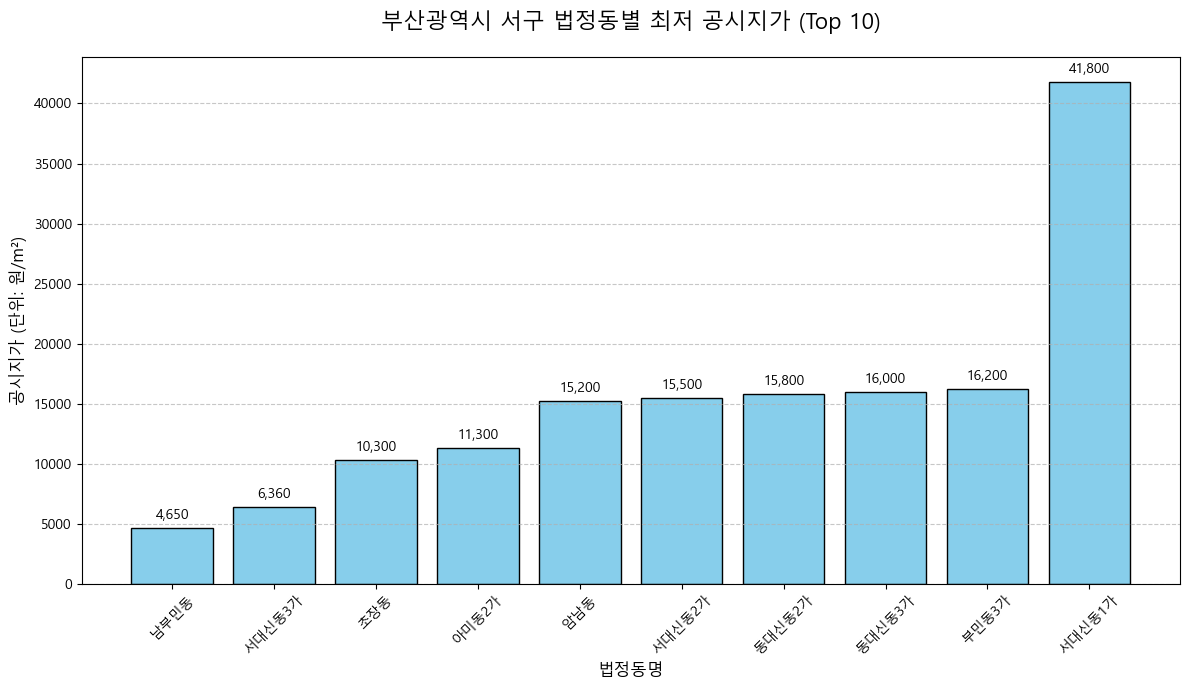

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 데이터 불러오기 (인코딩 에러 방지)
file_path = 'seogu_only_top10_low_price.csv'
try:
    df = pd.read_csv(file_path, encoding='utf-8-sig')
except:
    df = pd.read_csv(file_path, encoding='cp949')

# 2. 법정동명에서 '부산광역시 서구 ' 부분 제거
# "부산광역시 서구 남부민동" -> "남부민동"
df['Short_Dong'] = df['법정동명'].str.replace('부산광역시 서구 ', '', regex=False)

# 3. 한글 폰트 설정 (윈도우 기준: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. 막대그래프 생성
plt.figure(figsize=(12, 7))
bars = plt.bar(df['Short_Dong'], df['공시지가'], color='skyblue', edgecolor='black')

# 5. 그래프 꾸미기
plt.title('부산광역시 서구 법정동별 최저 공시지가 (Top 10)', fontsize=16, pad=20)
plt.xlabel('법정동명', fontsize=12)
plt.ylabel('공시지가 (단위: 원/m²)', fontsize=12) # 요청하신 단위 표기
plt.xticks(rotation=45) # 글자가 겹치지 않게 회전
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 실제 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# 그래프 출력
plt.show()

# (선택 사항) 그래프를 이미지로 저장하고 싶다면 아래 코드 주석 해제
# plt.savefig('seogu_land_price_graph.png', dpi=300)

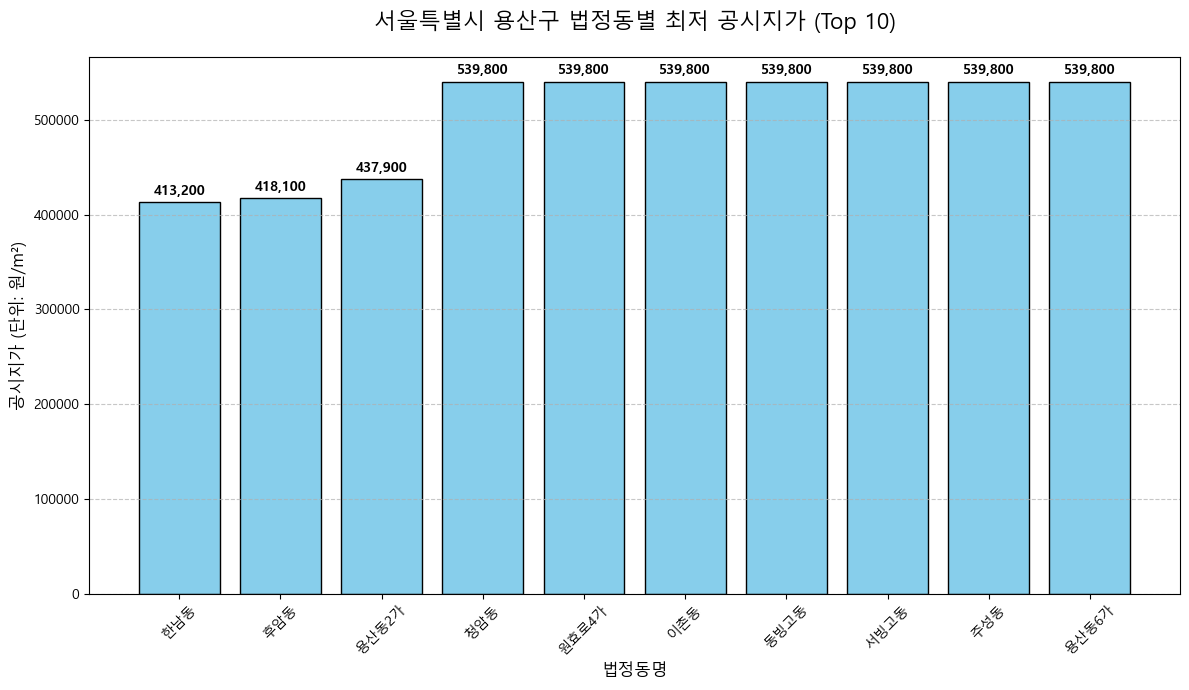

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
file_path = '서울특별시_용산구.csv'
try:
    # 한글 인코딩 대응 (cp949 우선 시도)
    df = pd.read_csv(file_path, encoding='cp949')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. '용산구' 데이터만 필터링 (강서구 등 타 구 제외 로직)
# 법정동명에 '용산구'가 포함된 행만 선택
df_yongsan = df[df['법정동명'].str.contains(r'\b용산구\b', regex=True, na=False)].copy()

# 3. '산' 제외 및 데이터 정제
df_filtered = df_yongsan[df_yongsan['특수지구분명'] != '산'].copy()
df_filtered['공시지가'] = pd.to_numeric(df_filtered['공시지가'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['공시지가'])

# 4. 법정동명 중복 제거 및 최저가 선정
# 낮은 가격순으로 정렬 후, 각 동네별로 가장 저렴한 필지 하나씩만 추출
df_sorted = df_filtered.sort_values(by='공시지가', ascending=True)
df_unique_dong = df_sorted.drop_duplicates(subset=['법정동명'], keep='first')

# 5. Top 10 선정
top_10_yongsan = df_unique_dong.head(10).copy()

# 6. 그래프 축을 위해 '서울특별시 용산구 ' 텍스트 제거
# 예: "서울특별시 용산구 이태원동" -> "이태원동"
top_10_yongsan['Short_Dong'] = top_10_yongsan['법정동명'].str.replace('서울특별시 용산구 ', '', regex=False)

# 7. 시각화 설정 (한글 폰트 및 스타일)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기준
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 7))
# 부산 서구와 동일한 타입의 막대그래프 (색상만 구분)
bars = plt.bar(top_10_yongsan['Short_Dong'], top_10_yongsan['공시지가'], color='skyblue', edgecolor='black')

# 8. 그래프 꾸미기 및 단위(원/m²) 명시
plt.title('서울특별시 용산구 법정동별 최저 공시지가 (Top 10)', fontsize=16, pad=20)
plt.xlabel('법정동명', fontsize=12)
plt.ylabel('공시지가 (단위: 원/m²)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 상단에 실제 가격 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01),
             f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# 결과 출력
plt.show()

# 필요한 경우 결과 데이터를 CSV로 저장
# top_10_yongsan.to_csv('yongsan_final_top10.csv', index=False, encoding='utf-8-sig')

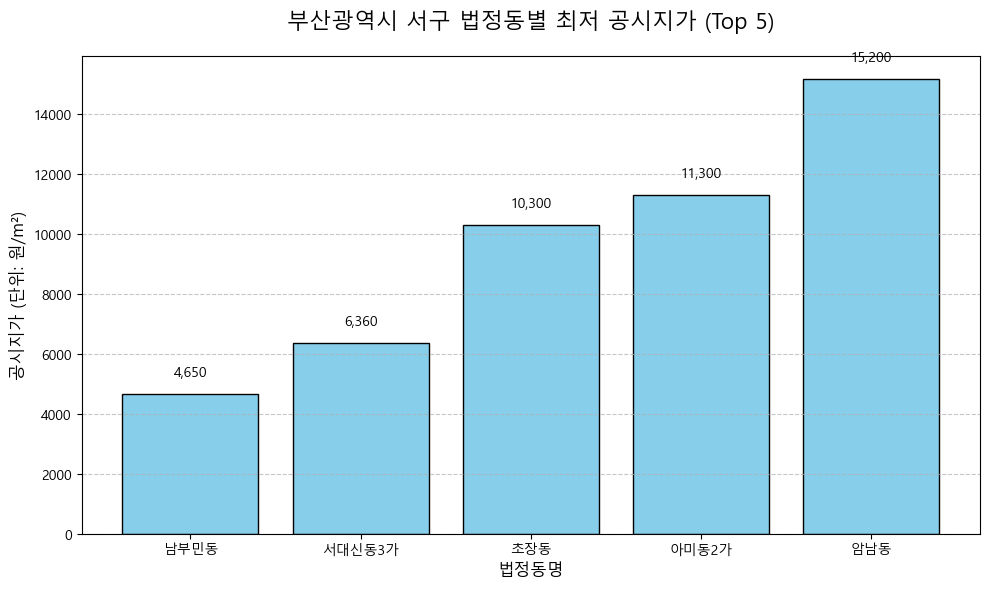

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 데이터 불러오기 (인코딩 에러 방지)
file_path = 'seogu_only_top10_low_price.csv'
try:
    df = pd.read_csv(file_path, encoding='utf-8-sig')
except:
    df = pd.read_csv(file_path, encoding='cp949')

# ★ Top 5만 추출하도록 데이터 자르기 추가
df = df.head(5)

# 2. 법정동명에서 '부산광역시 서구 ' 부분 제거
# "부산광역시 서구 남부민동" -> "남부민동"
df['Short_Dong'] = df['법정동명'].str.replace('부산광역시 서구 ', '', regex=False)

# 3. 한글 폰트 설정 (윈도우 기준: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. 막대그래프 생성
plt.figure(figsize=(10, 6)) # 5개 항목에 맞춰 그래프 크기 살짝 조정
bars = plt.bar(df['Short_Dong'], df['공시지가'], color='skyblue', edgecolor='black')

# 5. 그래프 꾸미기
# ★ 제목 Top 10 -> Top 5로 변경
plt.title('부산광역시 서구 법정동별 최저 공시지가 (Top 5)', fontsize=16, pad=20)
plt.xlabel('법정동명', fontsize=12)
plt.ylabel('공시지가 (단위: 원/m²)', fontsize=12) 
plt.xticks(rotation=0) # 항목이 5개라 글자가 겹치지 않으므로 회전(0도)으로 변경
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 실제 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# 그래프 출력
plt.show()

# (선택 사항) 그래프를 이미지로 저장하고 싶다면 아래 코드 주석 해제
# plt.savefig('seogu_land_price_top5_graph.png', dpi=300)

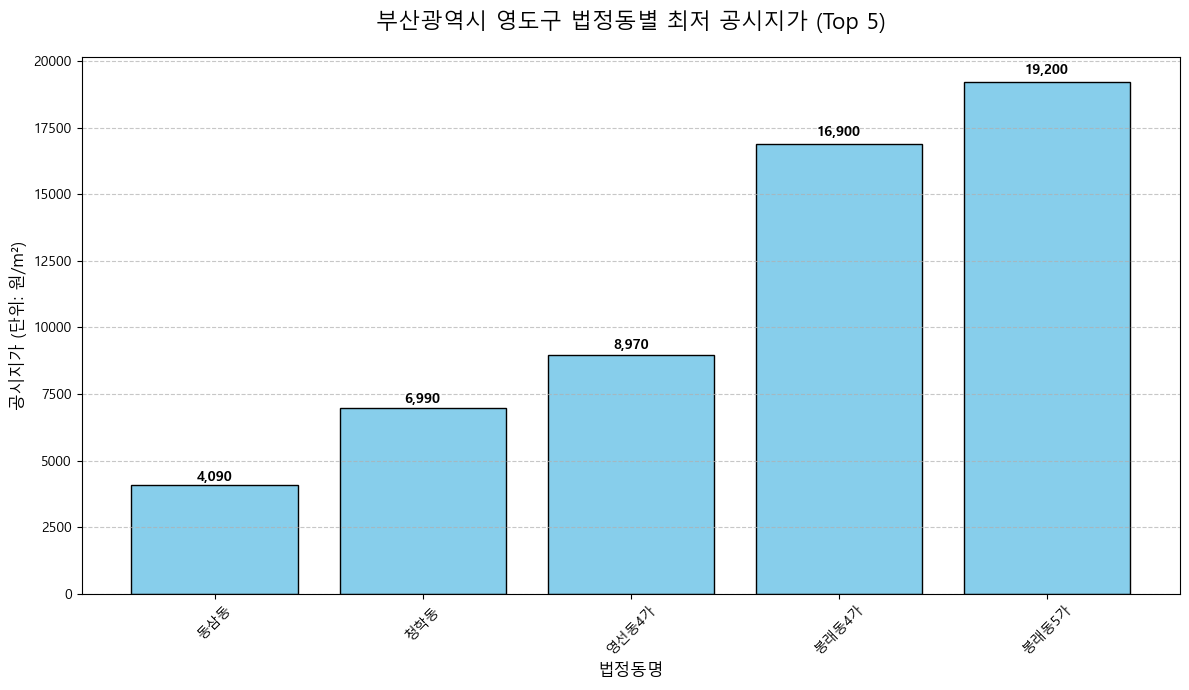

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 엑셀 데이터 불러오기
# 파일명이 '부산 영도구 공시지가.xlsx'라고 가정합니다.
file_path = '부산 영도구 공시지가.xlsx'

try:
    # 엑셀 파일을 읽습니다. (openpyxl 설치 필요: pip install openpyxl)
    df = pd.read_excel(file_path)
except Exception as e:
    print(f"파일을 읽는 중 오류가 발생했습니다: {e}")
    # 만약 위에서 업로드한 CSV 파일을 사용하시려면 아래 주석을 해제하세요.
    # df = pd.read_csv('부산 영도구 공시지가.xlsx - Sheet1.csv', encoding='utf-8-sig')

# 2. 필터링: '산' 제외
df_filtered = df[df['특수지구분명'] != '산'].copy()

# 3. 데이터 정제: 공시지가 숫자 변환 및 결측치 제거
df_filtered['공시지가'] = pd.to_numeric(df_filtered['공시지가'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['공시지가'])

# 4. 법정동명 중복 제거 (각 동별 최저가 1개씩 선정)
# 공시지가 낮은 순 정렬 후, 법정동명 기준 첫 번째 행만 유지
df_sorted = df_filtered.sort_values(by='공시지가', ascending=True)
df_unique_dong = df_sorted.drop_duplicates(subset=['법정동명'], keep='first')

# 5. Top 10 선정
top_10_yeongdo = df_unique_dong.head(10).copy()

# 6. 그래프 축을 위해 '부산광역시 영도구 ' 텍스트 제거
top_10_yeongdo['Short_Dong'] = top_10_yeongdo['법정동명'].str.replace('부산광역시 영도구 ', '', regex=False)

# 7. 시각화 설정 (한글 폰트 및 스타일)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기준
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 7))
# 서구와 동일한 하늘색(skyblue) 막대그래프
bars = plt.bar(top_10_yeongdo['Short_Dong'], top_10_yeongdo['공시지가'], color='skyblue', edgecolor='black')

# 8. 그래프 꾸미기 및 단위(원/m²) 명시
plt.title('부산광역시 영도구 법정동별 최저 공시지가 (Top 5)', fontsize=16, pad=20)
plt.xlabel('법정동명', fontsize=12)
plt.ylabel('공시지가 (단위: 원/m²)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 실제 수치 표시 (서구 코드와 동일한 방식)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (height * 0.01),
             f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# 그래프 출력
plt.show()

# 9. 요청하신 조건의 CSV 파일 생성
# top_10_yeongdo.to_csv('yeongdo_low_price_top10.csv', index=False, encoding='utf-8-sig')

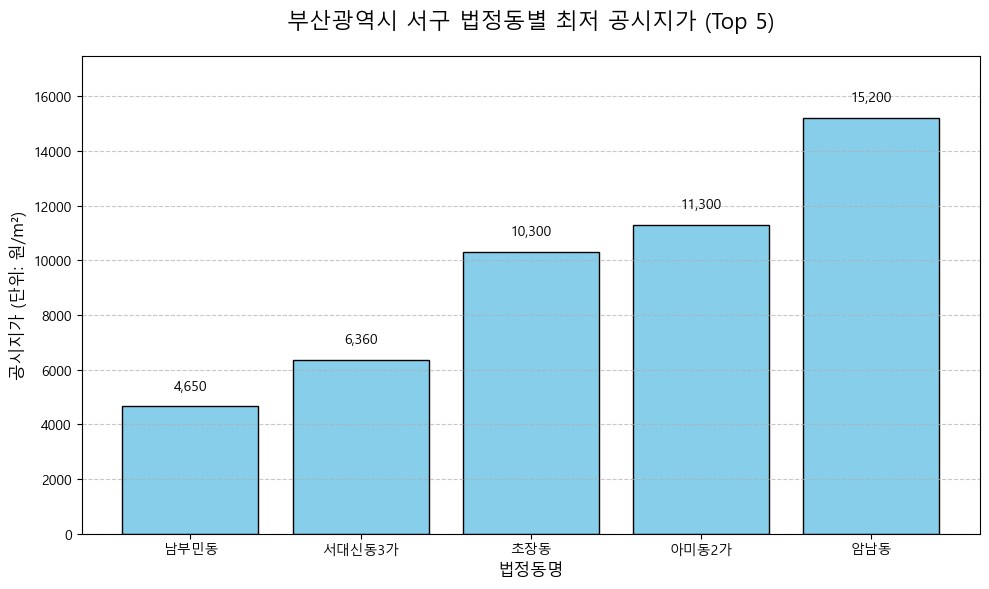

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 데이터 불러오기 (인코딩 에러 방지)
file_path = 'seogu_only_top10_low_price.csv'
try:
    df = pd.read_csv(file_path, encoding='utf-8-sig')
except:
    df = pd.read_csv(file_path, encoding='cp949')

# Top 5만 추출하도록 데이터 자르기
df = df.head(5)

# 2. 법정동명에서 '부산광역시 서구 ' 부분 제거
df['Short_Dong'] = df['법정동명'].str.replace('부산광역시 서구 ', '', regex=False)

# 3. 한글 폰트 설정 (윈도우 기준: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. 막대그래프 생성
plt.figure(figsize=(10, 6))
bars = plt.bar(df['Short_Dong'], df['공시지가'], color='skyblue', edgecolor='black')

# ★ y축 최대값 늘리기: 가장 높은 공시지가보다 15% 정도 더 높게 설정하여 글자가 잘리지 않게 함
plt.ylim(0, df['공시지가'].max() * 1.15)

# 5. 그래프 꾸미기
plt.title('부산광역시 서구 법정동별 최저 공시지가 (Top 5)', fontsize=16, pad=20)
plt.xlabel('법정동명', fontsize=12)
plt.ylabel('공시지가 (단위: 원/m²)', fontsize=12) 
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 실제 수치 표시
for bar in bars:
    height = bar.get_height()
    # 글자가 겹치지 않게 띄우는 높이(500)는 그대로 유지
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# 그래프 출력
plt.show()

# (선택 사항) 그래프를 이미지로 저장하고 싶다면 아래 코드 주석 해제
# plt.savefig('seogu_land_price_top5_graph.png', dpi=300)